# Exercise 3 and 4: $H_0$ and $M_B$ from Pantheon+ SH0ES with NUTS

Infer the Hubble constant $H_0$ and the supernova absolute magnitude $M_B$ with the No-U-Turn Sampler, one task per section.

**Before running:**
- using `nuts.py` 
- using data in `../data/` (`Pantheon+SH0ES.dat` and `Pantheon+SH0ES_STAT+SYS.cov`)

**Two data selections are used:**
- **HF only**: the 277 Hubble-flow SNe (`USED_IN_SH0ES_HF == 1`). Tasks 3–7 are about these.
- **HF + calibrators**: the Hubble flow plus the 77 SNe with Cepheid distances (`IS_CALIBRATOR == 1`). This was the selection in the previous run, and it is used again in Task 8.

## Task 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

from nuts import (sample, Uniform, Normal, log_prior, summary,
                  check_convergence, trace_plot, corner_plot,
                  joint_density, credible_thresholds, SERIES, INK, MUTED, GRID)

%matplotlib inline

In [2]:
# Sampler settings used by every run below
N_CHAINS  = 4
N_SAMPLES = 2000     # kept draws per chain
N_WARMUP  = 1000     # tuning iterations per chain
SEED      = 42

H0ref = 70.0         # reference H0 in M = MB - 5 log10(H0 / H0ref)

In [3]:
datfile = '../data/Pantheon+SH0ES.dat'
covfile = '../data/Pantheon+SH0ES_STAT+SYS.cov'

df = pd.read_csv(datfile, sep=r'\s+')      # first line = column names

zHDvals        = df['zHD'].values
m_b_corr_vals  = df['m_b_corr'].values
CEPH_DIST_vals = df['CEPH_DIST'].values
flag_calib     = df['IS_CALIBRATOR'].values
flag_hf        = df['USED_IN_SH0ES_HF'].values

mask_full = (flag_calib == 1) | (flag_hf == 1)   # calibrators + Hubble flow
mask_hf   = (flag_hf == 1) & (flag_calib == 0)   # Hubble flow only

# Covariance: first value is N, then the N x N matrix
cov_vals = np.loadtxt(covfile)
N = int(cov_vals[0])
C = cov_vals[1:].reshape(N, N)
assert N == len(df), "N in .cov file does not match rows in .dat file"

print(f"Total SNe: {len(df)}")
print(f"HF only: {mask_hf.sum()}")
print(f"HF + calibrators: {mask_full.sum()} ({(flag_calib == 1).sum()} calibrators)")

Total SNe: 1701
HF only: 277
HF + calibrators: 354 (77 calibrators)


### Model and likelihood

For a Hubble-flow supernova, $m = M_B + \mu(z)$ with $\mu = 5\log_{10}(d_L/\mathrm{Mpc}) + 25$.
For a calibrator, $\mu$ is the Cepheid distance modulus `CEPH_DIST`.
The log-likelihood uses the full covariance: $\ln L = -\tfrac12\, r^\top C^{-1} r$ with $\Delta = m_\mathrm{obs} - m_\mathrm{model}$.

In [4]:
c = 299792.458  # km/s

def luminosity_distance(z, H0, Om=0.3):
    # Luminosity distance in Mpc for flat LCDM (radiation neglected
    # Omega = 0.3
    OL = 1.0 - Om
    E = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + OL)
    integral, _ = quad(E, 0, z)
    return (1 + z) * (c / H0) * integral


def build_data(mask):
    # Everything the likelihood needs for one selection of supernovae
    z = zHDvals[mask]
    C_masked = C[np.ix_(mask, mask)]        # same rows AND columns
    # dL is proportional to 1/H0, so do the integrals once (with H0 = 1)
    dL_times_H0 = np.array([luminosity_distance(zi, 1.0) for zi in z])
    return {
        "m_obs": m_b_corr_vals[mask],
        "ceph": CEPH_DIST_vals[mask],
        "is_cal": flag_calib[mask] == 1,
        "dL_times_H0": dL_times_H0,
        "inv_cov": np.linalg.inv(C_masked),
    }


def mu1_model(H0, dL_times_H0):
    # mu from redshift: 5 log10(dL / Mpc) + 25, with dL = dL_times_H0 / H0
    mu_ref = 5 * np.log10(dL_times_H0 / H0ref) + 25     # mu for H0 = H0ref
    return mu_ref - 5 * np.log10(H0 / H0ref)


def residual(Mb, H0, data):
    # Calibrators: Cepheid distance; Hubble flow: distance from redshift
    mu = np.where(data["is_cal"], data["ceph"], mu1_model(H0, data["dL_times_H0"]))
    return data["m_obs"] - (Mb + mu)


def log_likelihood(theta, data):
    # Gaussian log-likelihood with the full covariance. theta = [H0, Mb]
    H0, Mb = theta
    r = residual(Mb, H0, data)
    return -0.5 * r @ data["inv_cov"] @ r


def M_combination(H0, Mb):
    # The combination the Hubble flow constrains: M = MB - 5 log10(H0 / H0ref)
    return Mb - 5 * np.log10(H0 / H0ref)


DATA = {"hf": build_data(mask_hf), "full": build_data(mask_full)}
DATA_LABEL = {"hf": "HF only", "full": "HF + calibrators"}

### Log priors

$$\ln p_U(x) = \begin{cases}-\ln(b-a) & a\le x\le b\\ -\infty & \text{otherwise}\end{cases}
\qquad
\ln p_N(x) = -\tfrac12\ln(2\pi\sigma^2) - \frac{(x-\mu)^2}{2\sigma^2}$$

The two parameters are independent, so $\ln p(H_0, M_B) = \ln p(H_0) + \ln p(M_B)$. $H_0 \sim \mathcal U(50, 100)$ in every case.

The sampler needs each prior as an object (`Uniform`, `Normal`) so it knows which parameters are bounded. The check at the end of the cell confirms that the objects give exactly the same values as the explicit functions.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ---------------------------------------------------------------
# 1. Read the .dat file, extract the 5 columns, build the mask
# ---------------------------------------------------------------
datfile = '../data/Pantheon+SH0ES.dat'
covfile = '../data/Pantheon+SH0ES_STAT+SYS.cov'

df = pd.read_csv(datfile, sep=r'\s+')      # first line = column names

zHDvals        = df['zHD'].values
m_b_corr_vals  = df['m_b_corr'].values
CEPH_DIST_vals = df['CEPH_DIST'].values
flag_calib     = df['IS_CALIBRATOR'].values
flag_hf        = df['USED_IN_SH0ES_HF'].values

mask = (df['IS_CALIBRATOR'] == 1) | (df['USED_IN_SH0ES_HF'] == 1)
mask = mask.values

z      = zHDvals[mask]
m_obs  = m_b_corr_vals[mask]
ceph   = CEPH_DIST_vals[mask]
is_cal = flag_calib[mask] == 1

print(f"Total SNe: {len(df)},  after mask: {mask.sum()} " f"({is_cal.sum()} calibrators, {(~is_cal).sum()} Hubble flow)")

# ---------------------------------------------------------------
# 2. Covariance: skip first line (N), reshape to N x N, apply mask
# ---------------------------------------------------------------
cov_vals = np.loadtxt(covfile)              # first value is N
N = int(cov_vals[0])
C = cov_vals[1:].reshape(N, N)
assert N == len(df), "N in .cov file does not match rows in .dat file"

C_masked = C[np.ix_(mask, mask)]            # same rows AND columns
inv_cov  = np.linalg.inv(C_masked)
print("Masked covariance shape:", C_masked.shape)
# ---------------------------------------------------------------
# 3. Luminosity distance and distance modulus
# ---------------------------------------------------------------
c = 299792.458  # km/s
def luminosity_distance(z, H0, Om=0.3):
    """Luminosity distance in Mpc for flat LCDM (radiation neglected)."""
    OL = 1.0 - Om
    E = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + OL)
    integral, _ = quad(E, 0, z)
    return (1 + z) * (c / H0) * integral

# Speed-up: dL is proportional to 1/H0, so do the integrals ONCE (with H0=1)
# and just divide by H0 later. Same result, ~1000x faster inside the MCMC.
dL_times_H0 = np.array([luminosity_distance(zi, 1.0) for zi in z])

def mu1_model(H0):
    """mu from redshift: 5 log10(dL) + 25.
    change from 174 in notes"""
    DL = dL_times_H0# / H0
    H0ref = 70
    mu_ref = 5 * np.log10(DL/H0ref) + 25
    return mu_ref - 5* np.log10(H0/H0ref)

# ---------------------------------------------------------------
# 4. Residual, log-likelihood, prior, posterior
# ---------------------------------------------------------------
def residual(Mb, H0):
    # Calibrators: distance from Cepheids (mu2 = CEPH_DIST)
    # Hubble flow: distance from redshift (mu1 = 5 log10 dL + 25)
    mu = np.where(is_cal, ceph, mu1_model(H0))
    m_model = Mb + mu
    return m_obs - m_model

def log_likelihood(Mb, H0, inv_cov, const=0.0):
    r = residual(Mb, H0)
    return -0.5 * r @ inv_cov @ r + const


#  check this with instructor
H0_bounds = (50, 100)          # Uniform prior on H0: (lower, upper)
Mb_bounds = (-19.3, 0.01)      # Gaussian prior on Mb: (mean, sigma)

def log_unformprior(theta):
    """Uniform prior: log(1)=0 inside the box, log(0)=-inf outside."""
    H0, Mb = theta
    if H0_bounds[0] < H0 < H0_bounds[1] and Mb_bounds[0] < Mb < Mb_bounds[1]:
        return 0.0
    return -np.inf


def log_uniform_pdf(x, a, b):
    if a <= x <= b:
        return -np.log(b - a)
    return -np.inf

def log_gaussian_pdf(x, mu, sigma):
    return -0.5 * np.log(2 * np.pi * sigma**2) - (x - mu)**2 / (2 * sigma**2)


def log_prior(theta, a=H0_bounds[0], b=H0_bounds[1], mu=Mb_bounds[0], sigma=Mb_bounds[1]):
    """
    Log of the joint density of two independent parameters.

    theta1 follows a Uniform(a, b) distribution and theta2 follows a
    Normal(mu, sigma) distribution. Because they are independent, the
    joint density is the product of the two densities, so its log is
    the sum of the two log densities:

        log p(theta1, theta2) = log p_U(theta1) + log p_N(theta2)

    Parameters
    ----------
    theta : array_like of length 2
        The two parameter values ``(theta1, theta2)``.
    a : float
        Lower bound of the uniform distribution for theta1.
    b : float
        Upper bound of the uniform distribution for theta1. Must be > a.
    mu : float
        Mean of the Gaussian distribution for theta2.
    sigma : float
        Standard deviation of the Gaussian distribution for theta2.
        Must be > 0.

    Returns
    -------
    float
        The log joint density at ``theta``. Returns ``-np.inf`` if
        theta1 lies outside ``[a, b]``, where the density is zero.

    Examples
    --------
    >>> log_prior([3.0, 4.5], a=0.0, b=10.0, mu=5.0, sigma=2.0)
    -3.9395...
    """
    theta1, theta2 = theta
    lp = log_uniform_pdf(theta1, a, b)
    if not np.isfinite(lp):  # outside the uniform bounds
        return -np.inf
    return lp + log_gaussian_pdf(theta2, mu, sigma)

def log_posterior(theta, inv_cov, const=0.0):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf             # outside bounds: skip the likelihood
    H0, Mb = theta
    return lp + log_likelihood(Mb, H0, inv_cov, const)


Total SNe: 1701,  after mask: 354 (77 calibrators, 277 Hubble flow)
Masked covariance shape: (354, 354)


chain 1/4: step size 0.481, accept 0.94, divergences 0, mean tree depth 2.6
chain 2/4: step size 0.547, accept 0.92, divergences 0, mean tree depth 2.4
chain 3/4: step size 0.530, accept 0.93, divergences 0, mean tree depth 2.5
chain 4/4: step size 0.585, accept 0.92, divergences 0, mean tree depth 2.4
   param       mean         sd       2.5%        50%      97.5%  r_hat  ess_bulk  ess_tail
      H0    71.9525     0.4249    71.1368    71.9546    72.8026  1.001      2126      2627
      Mb   -19.2947     0.0094   -19.3128   -19.2949   -19.2761  1.001      2792      4131
Saved trace.png and corner.png


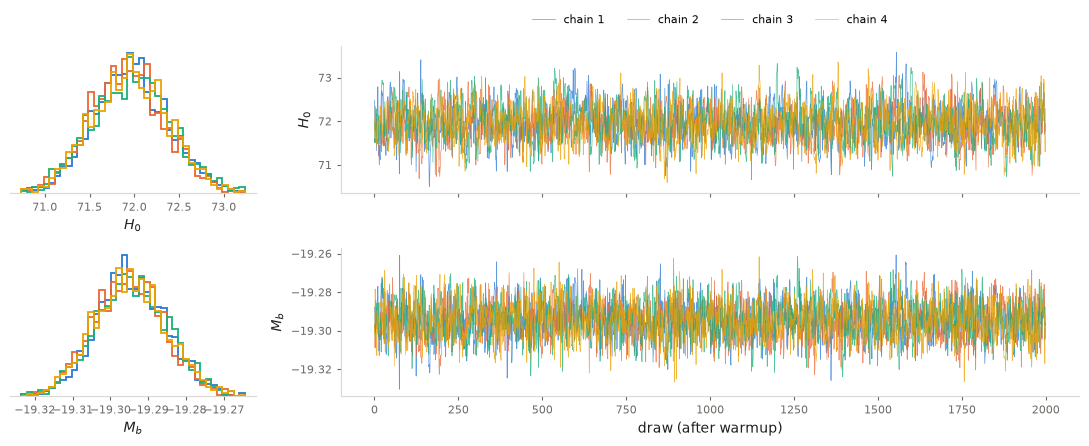

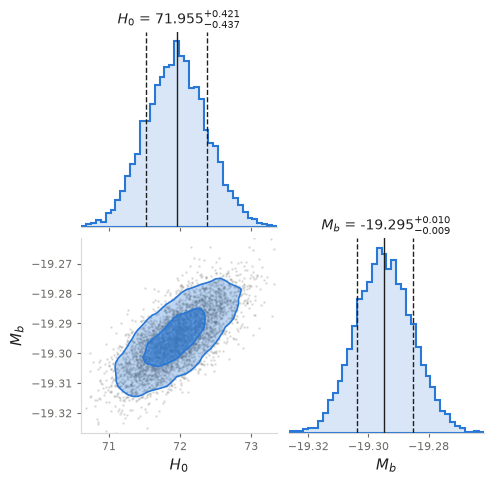

In [9]:
# ---------------------------------------------------------------
# 5. Sample the posterior with NUTS
# ---------------------------------------------------------------
from nuts import sample_posterior, summary, corner_plot, trace_plot

def log_likelihood_theta(theta, inv_cov):
    """Adapter for nuts.py, which passes theta = [theta1, theta2].

    theta1 = H0 (uniform prior), theta2 = Mb (gaussian prior).
    """
    H0, Mb = theta
    return log_likelihood(Mb, H0, inv_cov)

a, b = H0_bounds          # uniform prior on H0
mu, sigma = Mb_bounds     # gaussian prior on Mb

chains, info = sample_posterior(log_likelihood_theta, a, b, mu, sigma,
                                n_chains=4, n_samples=2000, n_warmup=1000,
                                seed=42, args=(inv_cov,))

names = [r"$H_0$", r"$M_b$"]
summary(chains, names=["H0", "Mb"])

# ---------------------------------------------------------------
# 6. Plots
# ---------------------------------------------------------------
trace_plot(chains, names=names, filename="trace.png")
corner_plot(chains, names=names, filename="corner.png")
print("Saved trace.png and corner.png")
plt.show()

In [10]:
names = ["H0", "MB"]
for i, name in enumerate(names):
    print('rhat for ', name)
    x = chains[:, :, i]  
    #Classic (Gelman-Rubin) R-hat for chains x of shape (m, n)."""
    n = x.shape[1]
    W = x.var(axis=1, ddof=1).mean()
    B = n * x.mean(axis=1).var(ddof=1)
    if W == 0:
        print('escpae')
        rhat = None
    else:
        rhat = float(np.sqrt(((n - 1) / n * W + B / n) / W))
    print(' = ', rhat)

rhat for  H0
 =  1.001294086988978
rhat for  MB
 =  1.0007805543671149


In [12]:
#
from nuts import  ess_bulk, ess_tail
names = ["H0", "MB"]
for i, name in enumerate(names):
    x = chains[:, :, i]            # shape (n_chains, n_draws) for one parameter
    print(f"bulk ESS = {ess_bulk(x):.0f}, tail ESS = {ess_tail(x):.0f}")

n_div = sum(res["n_divergent"] for res in info)
print("divergences:", n_div)

bulk ESS = 2126, tail ESS = 2627
bulk ESS = 2792, tail ESS = 4131
divergences: 0


In [ ]:
#Reasoning: Looking at the corner plots seems like the posteriors are twoo narrow. they seems goods but looks like
# parameter space is not well explored maybe its funnel?

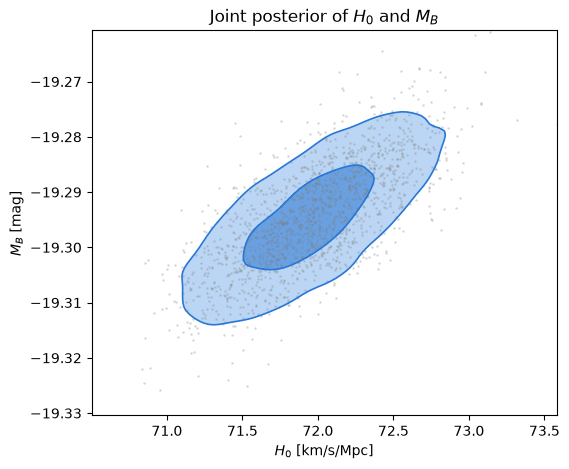

In [13]:
# Exercise 4:  joint density
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Pool all chains: chains has shape (n_chains, n_draws, 2) = [H0, MB]
H0 = chains[:, :, 0].ravel()
MB = chains[:, :, 1].ravel()

# Smooth 2D density estimate from the samples
kde = gaussian_kde(np.vstack([H0, MB]))

# Evaluate it on a grid
x = np.linspace(H0.min(), H0.max(), 100)
y = np.linspace(MB.min(), MB.max(), 100)
X, Y = np.meshgrid(x, y)

Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# Density levels enclosing 39% and 86% of the samples (1σ and 2σ in 2D)
dens = kde(np.vstack([H0, MB]))
levels = np.percentile(dens, [100 - 86.5, 100 - 39.3])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(H0[::5], MB[::5], ".", color="gray", alpha=0.2, markersize=2)   # the samples
ax.contourf(X, Y, Z, levels=[levels[0], levels[1], Z.max()],
            colors=["#9ec5f0", "#2a78d6"], alpha=0.7)                  # filled regions
ax.contour(X, Y, Z, levels=levels, colors="#2a78d6", linewidths=1.2)   # outlines
ax.set_xlabel(r"$H_0$ [km/s/Mpc]")
ax.set_ylabel(r"$M_B$ [mag]")
ax.set_title("Joint posterior of $H_0$ and $M_B$")
plt.savefig("joint_density.png", dpi=150, bbox_inches="tight")
plt.show()

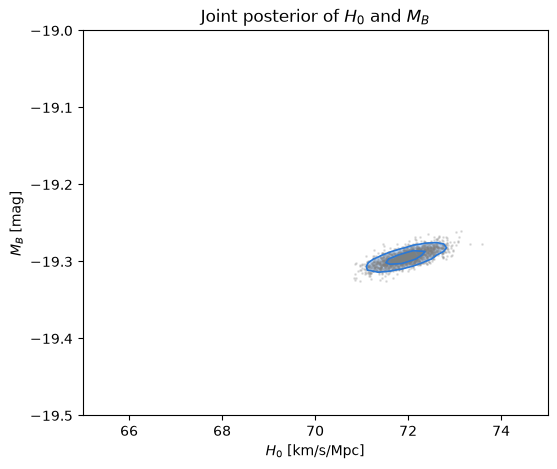

In [17]:
# Exercise 4:  joint density with prior based grid
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Pool all chains: chains has shape (n_chains, n_draws, 2) = [H0, MB]
H0 = chains[:, :, 0].ravel()
MB = chains[:, :, 1].ravel()

# Smooth 2D density estimate from the samples
kde = gaussian_kde(np.vstack([H0, MB]))

# Evaluate it on a grid
x = np.linspace(H0.min(), H0.max(), 100)
y = np.linspace(MB.min(), MB.max(), 100)
X, Y = np.meshgrid(x, y)

# Prior limits
H0_lo, H0_hi = 50, 100            # H0 ~ U(50, 100)
mu_MB, sig_MB = -19.0, 0.12       # MB ~ N(-19, 0.12)
k = 4                             # how many sigma to show
MB_lo, MB_hi = mu_MB - k * sig_MB, mu_MB + k * sig_MB   # -19.48 to -18.52

# Grid over the prior range
x = np.linspace(H0_lo, H0_hi, 200)
y = np.linspace(MB_lo, MB_hi, 200)
X, Y = np.meshgrid(x, y)


Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# Density levels enclosing 39% and 86% of the samples (1σ and 2σ in 2D)
dens = kde(np.vstack([H0, MB]))
levels = np.percentile(dens, [100 - 86.5, 100 - 39.3])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(H0[::5], MB[::5], ".", color="gray", alpha=0.2, markersize=2)   # the samples
ax.contourf(X, Y, Z, levels=[levels[0], levels[1], Z.max()],
            colors=["#9ec5f0", "#2a78d6"], alpha=0.7)                  # filled regions
ax.contour(X, Y, Z, levels=levels, colors="#2a78d6", linewidths=1.2)   # outlines
ax.set_xlabel(r"$H_0$ [km/s/Mpc]")
ax.set_ylabel(r"$M_B$ [mag]")
ax.set_title("Joint posterior of $H_0$ and $M_B$")
ax.set_xlim(65, 75)
ax.set_ylim(-19.5, -19.)
plt.savefig("joint_density.png", dpi=150, bbox_inches="tight")
plt.show()

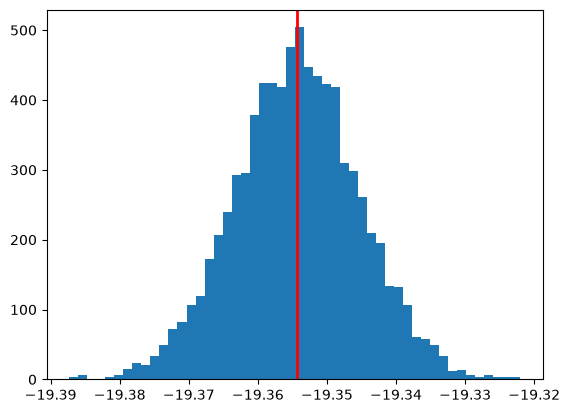

In [24]:
H0 = chains[:, :, 0].ravel()
MB = chains[:, :, 1].ravel()
def M(Mb_posteriors, H0_posteriors):
    return Mb_posteriors - 5 * np.log10(H0_posteriors/70.0)

Mposteriors = M(MB, H0)
plt.hist(Mposteriors, bins=50)
plt.axvline(x=np.mean(Mposteriors), color='r', lw=2)
plt.show()

In [25]:
# part 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ---------------------------------------------------------------
# 1. Read the .dat file, extract the 5 columns, build the mask
# ---------------------------------------------------------------
datfile = '../data/Pantheon+SH0ES.dat'
covfile = '../data/Pantheon+SH0ES_STAT+SYS.cov'

df = pd.read_csv(datfile, sep=r'\s+')      # first line = column names

zHDvals        = df['zHD'].values
m_b_corr_vals  = df['m_b_corr'].values
CEPH_DIST_vals = df['CEPH_DIST'].values
flag_calib     = df['IS_CALIBRATOR'].values
flag_hf        = df['USED_IN_SH0ES_HF'].values

mask = (df['IS_CALIBRATOR'] == 1) | (df['USED_IN_SH0ES_HF'] == 1)
mask = mask.values

z      = zHDvals[mask]
m_obs  = m_b_corr_vals[mask]
ceph   = CEPH_DIST_vals[mask]
is_cal = flag_calib[mask] == 1

print(f"Total SNe: {len(df)},  after mask: {mask.sum()} " f"({is_cal.sum()} calibrators, {(~is_cal).sum()} Hubble flow)")

# ---------------------------------------------------------------
# 2. Covariance: skip first line (N), reshape to N x N, apply mask
# ---------------------------------------------------------------
cov_vals = np.loadtxt(covfile)              # first value is N
N = int(cov_vals[0])
C = cov_vals[1:].reshape(N, N)
assert N == len(df), "N in .cov file does not match rows in .dat file"

C_masked = C[np.ix_(mask, mask)]            # same rows AND columns
inv_cov  = np.linalg.inv(C_masked)
print("Masked covariance shape:", C_masked.shape)
# ---------------------------------------------------------------
# 3. Luminosity distance and distance modulus
# ---------------------------------------------------------------
c = 299792.458  # km/s
def luminosity_distance(z, H0, Om=0.3):
    """Luminosity distance in Mpc for flat LCDM (radiation neglected)."""
    OL = 1.0 - Om
    E = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + OL)
    integral, _ = quad(E, 0, z)
    return (1 + z) * (c / H0) * integral

# Speed-up: dL is proportional to 1/H0, so do the integrals ONCE (with H0=1)
# and just divide by H0 later. Same result, ~1000x faster inside the MCMC.
dL_times_H0 = np.array([luminosity_distance(zi, 1.0) for zi in z])

def mu1_model(H0):
    """mu from redshift: 5 log10(dL) + 25.
    change from 174 in notes"""
    DL = dL_times_H0# / H0
    H0ref = 70
    mu_ref = 5 * np.log10(DL/H0ref) + 25
    return mu_ref - 5* np.log10(H0/H0ref)

# ---------------------------------------------------------------
# 4. Residual, log-likelihood, prior, posterior
# ---------------------------------------------------------------
def residual(Mb, H0):
    # Calibrators: distance from Cepheids (mu2 = CEPH_DIST)
    # Hubble flow: distance from redshift (mu1 = 5 log10 dL + 25)
    mu = np.where(is_cal, ceph, mu1_model(H0))
    m_model = Mb + mu
    return m_obs - m_model

def log_likelihood(Mb, H0, inv_cov, const=0.0):
    r = residual(Mb, H0)
    return -0.5 * r @ inv_cov @ r + const


#  check this with instructor
H0_bounds = (50, 100)          # Uniform prior on H0: (lower, upper)
Mb_bounds = (-19.2, 0.01)      # Gaussian prior on Mb: (mean, sigma)

def log_unformprior(theta):
    """Uniform prior: log(1)=0 inside the box, log(0)=-inf outside."""
    H0, Mb = theta
    if H0_bounds[0] < H0 < H0_bounds[1] and Mb_bounds[0] < Mb < Mb_bounds[1]:
        return 0.0
    return -np.inf


def log_uniform_pdf(x, a, b):
    if a <= x <= b:
        return -np.log(b - a)
    return -np.inf

def log_gaussian_pdf(x, mu, sigma):
    return -0.5 * np.log(2 * np.pi * sigma**2) - (x - mu)**2 / (2 * sigma**2)


def log_prior(theta, a=H0_bounds[0], b=H0_bounds[1], mu=Mb_bounds[0], sigma=Mb_bounds[1]):
    """
    Log of the joint density of two independent parameters.

    theta1 follows a Uniform(a, b) distribution and theta2 follows a
    Normal(mu, sigma) distribution. Because they are independent, the
    joint density is the product of the two densities, so its log is
    the sum of the two log densities:

        log p(theta1, theta2) = log p_U(theta1) + log p_N(theta2)

    Parameters
    ----------
    theta : array_like of length 2
        The two parameter values ``(theta1, theta2)``.
    a : float
        Lower bound of the uniform distribution for theta1.
    b : float
        Upper bound of the uniform distribution for theta1. Must be > a.
    mu : float
        Mean of the Gaussian distribution for theta2.
    sigma : float
        Standard deviation of the Gaussian distribution for theta2.
        Must be > 0.

    Returns
    -------
    float
        The log joint density at ``theta``. Returns ``-np.inf`` if
        theta1 lies outside ``[a, b]``, where the density is zero.

    Examples
    --------
    >>> log_prior([3.0, 4.5], a=0.0, b=10.0, mu=5.0, sigma=2.0)
    -3.9395...
    """
    theta1, theta2 = theta
    lp = log_uniform_pdf(theta1, a, b)
    if not np.isfinite(lp):  # outside the uniform bounds
        return -np.inf
    return lp + log_gaussian_pdf(theta2, mu, sigma)

def log_posterior(theta, inv_cov, const=0.0):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf             # outside bounds: skip the likelihood
    H0, Mb = theta
    return lp + log_likelihood(Mb, H0, inv_cov, const)


Total SNe: 1701,  after mask: 354 (77 calibrators, 277 Hubble flow)
Masked covariance shape: (354, 354)


chain 1/4: step size 0.454, accept 0.93, divergences 0, mean tree depth 2.4
chain 2/4: step size 0.526, accept 0.92, divergences 0, mean tree depth 2.3
chain 3/4: step size 0.463, accept 0.93, divergences 0, mean tree depth 2.4
chain 4/4: step size 0.510, accept 0.93, divergences 0, mean tree depth 2.3
   param       mean         sd       2.5%        50%      97.5%  r_hat  ess_bulk  ess_tail
      H0    74.9729     0.4367    74.1182    74.9635    75.8153  1.001      2097      2754
      Mb   -19.2046     0.0093   -19.2227   -19.2047   -19.1862  1.000      2749      3149
Saved trace.png and corner.png


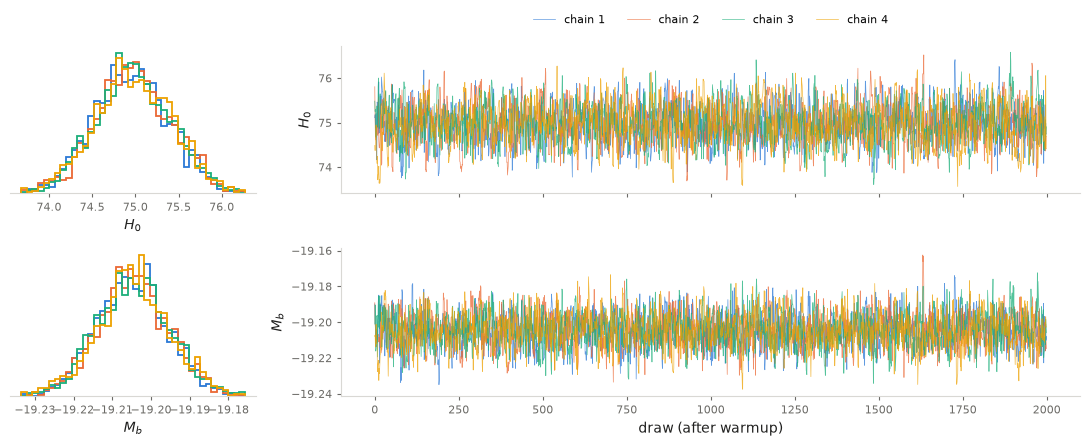

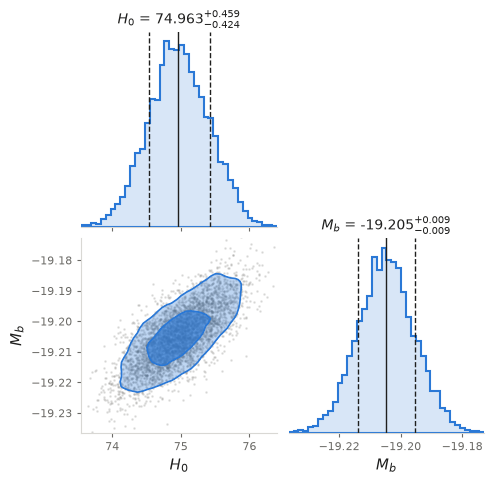

In [26]:
from nuts import sample_posterior, summary, corner_plot, trace_plot

def log_likelihood_theta(theta, inv_cov):
    """Adapter for nuts.py, which passes theta = [theta1, theta2].

    theta1 = H0 (uniform prior), theta2 = Mb (gaussian prior).
    """
    H0, Mb = theta
    return log_likelihood(Mb, H0, inv_cov)

a, b = H0_bounds          # uniform prior on H0
mu, sigma = Mb_bounds     # gaussian prior on Mb

chains, info = sample_posterior(log_likelihood_theta, a, b, mu, sigma,
                                n_chains=4, n_samples=2000, n_warmup=1000,
                                seed=42, args=(inv_cov,))

names = [r"$H_0$", r"$M_b$"]
summary(chains, names=["H0", "Mb"])

# ---------------------------------------------------------------
# 6. Plots
# ---------------------------------------------------------------
trace_plot(chains, names=names, filename="trace.png")
corner_plot(chains, names=names, filename="corner.png")
print("Saved trace.png and corner.png")
plt.show()

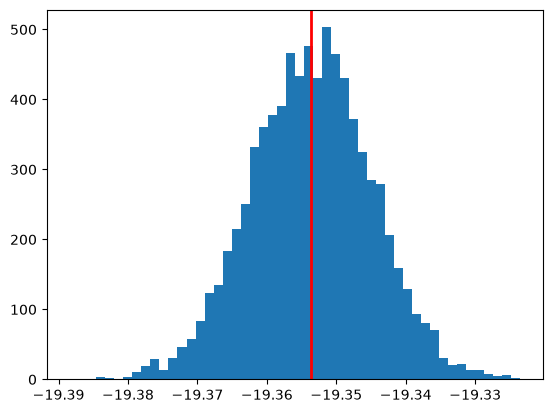

In [27]:
H0 = chains[:, :, 0].ravel()
MB = chains[:, :, 1].ravel()
def M(Mb_posteriors, H0_posteriors):
    return Mb_posteriors - 5 * np.log10(H0_posteriors/70.0)

Mposteriors = M(MB, H0)
plt.hist(Mposteriors, bins=50)
plt.axvline(x=np.mean(Mposteriors), color='r', lw=2)
plt.show()

In [29]:
# broad priors
H0_bounds = (50, 100)          # Uniform prior on H0: (lower, upper)
Mb_bounds = (-20.5, -18)
def log_prior(theta, a=H0_bounds[0], b=H0_bounds[1], a2=Mb_bounds[0], b2=Mb_bounds[1]):
    """
    Log of the joint density of two independent parameters.

    theta1 follows a Uniform(a, b) distribution and theta2 follows a
    Normal(mu, sigma) distribution. Because they are independent, the
    joint density is the product of the two densities, so its log is
    the sum of the two log densities:

        log p(theta1, theta2) = log p_U(theta1) + log p_N(theta2)

    Parameters
    ----------
    theta : array_like of length 2
        The two parameter values ``(theta1, theta2)``.
    a : float
        Lower bound of the uniform distribution for theta1.
    b : float
        Upper bound of the uniform distribution for theta1. Must be > a.
    mu : float
        Mean of the Gaussian distribution for theta2.
    sigma : float
        Standard deviation of the Gaussian distribution for theta2.
        Must be > 0.

    Returns
    -------
    float
        The log joint density at ``theta``. Returns ``-np.inf`` if
        theta1 lies outside ``[a, b]``, where the density is zero.

    Examples
    --------
    >>> log_prior([3.0, 4.5], a=0.0, b=10.0, mu=5.0, sigma=2.0)
    -3.9395...
    """
    theta1, theta2 = theta
    lp = log_uniform_pdf(theta1, a, b)
    if not np.isfinite(lp):  # outside the uniform bounds
        return -np.inf
    lp2 = log_uniform_pdf(theta2, a2, b2)
    if not np.isfinite(lp2):  # outside the uniform bounds
        return -np.inf
    return lp + lp2 


def log_likelihood_theta(theta, inv_cov):
    """Adapter for nuts.py, which passes theta = [theta1, theta2].

    theta1 = H0 (uniform prior), theta2 = Mb (gaussian prior).
    """
    H0, Mb = theta
    return log_likelihood(Mb, H0, inv_cov)

a, b = H0_bounds          # uniform prior on H0
mu,sigma = Mb_bounds     # gaussian prior on Mb

chains, info = sample_posterior(log_likelihood_theta, a, b, mu , sigma,
                                n_chains=4, n_samples=2000, n_warmup=1000,
                                seed=42, args=(inv_cov,))

names = [r"$H_0$", r"$M_b$"]
summary(chains, names=["H0", "Mb"])

# ---------------------------------------------------------------
# 6. Plots
# ---------------------------------------------------------------
trace_plot(chains, names=names, filename="trace.png")
corner_plot(chains, names=names, filename="corner.png")
print("Saved trace.png and corner.png")
plt.show()

ValueError: Normal prior needs sigma > 0.

In [ ]:


def log_prior_gauss(theta):
    # Task 4: H0 ~ U(50, 100), MB ~ N(-19.2, 0.12)
    H0, Mb = theta
    return log_uniform_pdf(H0, *H0_bounds) + log_gaussian_pdf(Mb, -19.2, 0.12)

def log_prior_flat(theta):
    # Task 5: H0 ~ U(50, 100), MB ~ U(-20.5, -18)
    H0, Mb = theta
    return log_uniform_pdf(H0, *H0_bounds) + log_uniform_pdf(Mb, -20.5, -18.0)

# The same priors as objects for the sampler, with a plot label
PRIORS = {
    "tight": ([Uniform(*H0_bounds), Normal(-19.3, 0.01)], log_prior_previous,
              r"$M_B\sim\mathcal{N}(-19.3,\ 0.01)$"),
    "gauss": ([Uniform(*H0_bounds), Normal(-19.2, 0.12)], log_prior_gauss,
              r"$M_B\sim\mathcal{N}(-19.2,\ 0.12)$"),
    "flat":  ([Uniform(*H0_bounds), Uniform(-20.5, -18.0)], log_prior_flat,
              r"$M_B\sim\mathcal{U}(-20.5,\ -18)$"),
}

# Check: explicit functions == prior objects
rng = np.random.default_rng(0)
for key, (priors, fn, _) in PRIORS.items():
    for _ in range(200):
        th = [rng.uniform(40, 110), rng.uniform(-21, -17.5)]
        a_, b_ = fn(th), log_prior(th, priors)
        assert (a_ == b_ == -np.inf) or np.isclose(a_, b_), key
print("Prior check passed.")

In [ ]:
names3 = [r"$H_0$", r"$M_B$", r"$\mathcal{M}$"]
results = {}

def run_case(data_key, prior_key, plots=True):
    # Sample one (data, prior) case, add M for every draw, print diagnostics
    case = f"{data_key}_{prior_key}"
    priors, _, prior_label = PRIORS[prior_key]
    print(f"{case}: {DATA_LABEL[data_key]}, H0 ~ {priors[0]}, MB ~ {priors[1]}\n")

    chains, info = sample(log_likelihood, priors, n_chains=N_CHAINS,
                          n_samples=N_SAMPLES, n_warmup=N_WARMUP, seed=SEED,
                          args=(DATA[data_key],))
    M = M_combination(chains[..., 0], chains[..., 1])
    chains3 = np.concatenate([chains, M[..., None]], axis=-1)

    print()
    summary(chains3, names=["H0", "MB", "M"])
    ok = check_convergence(chains, info, names=["H0", "MB"])
    if plots:
        trace_plot(chains3, info, names=names3, filename=f"trace_{case}.png")
        plt.show()
        corner_plot(chains3, names=names3, filename=f"corner_{case}.png")
        plt.show()
    results[case] = {"data": data_key, "prior": prior_key, "label": prior_label,
                     "chains": chains, "info": info,
                     "H0": chains[..., 0].ravel(), "MB": chains[..., 1].ravel(),
                     "M": M.ravel(), "converged": ok}
    return results[case]


def style(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)


def joint_contours(ax, H0, MB, color, label, level=0.865, fill=True,
                   linestyle="-", dots=True):
    # Joint posterior of (H0, MB): faint draws plus the region holding `level` of the mass
    from matplotlib.colors import to_rgba
    if dots:
        step = max(1, len(H0) // 2500)
        ax.plot(H0[::step], MB[::step], ".", color=color, alpha=0.12,
                markersize=2.5, zorder=1)
    xc, yc, H = joint_density(H0, MB, bins=90, smooth=1.5,
                              ranges=[(48, 102), (-20.6, -17.9)])
    th = credible_thresholds(H, [level])
    if fill:
        ax.contourf(xc, yc, H.T, levels=list(th) + [H.max() * 1.001],
                    colors=[to_rgba(color, 0.2)], zorder=2)
    ax.contour(xc, yc, H.T, levels=th, colors=[color], linewidths=1.6,
               linestyles=linestyle, zorder=3)
    ax.plot([], [], color=color, linewidth=1.6, linestyle=linestyle, label=label)


def joint_axes(ax, title):
    ax.set_xlim(48, 102)
    ax.set_ylim(-20.6, -17.9)
    ax.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", color=INK)
    ax.set_ylabel(r"$M_B$  [mag]", color=INK)
    ax.set_title(title, color=INK, fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    style(ax)


def mean_sd(x):
    return f"{np.mean(x):.3f} ± {np.std(x, ddof=1):.3f}"

## Previous run: HF + calibrators, $M_B \sim \mathcal N(-19.3,\ 0.01)$

This reproduces the earlier result, as the baseline for comparing the later tasks.

In [ ]:
prev = run_case("full", "tight", plots=False)

## Task 1: Trace plots, $\hat R$, effective sample size and divergences

**How to judge convergence.** All four of these should hold:

| Check | Target | What it means if it fails |
|---|---|---|
| $\hat R$ (rank-normalised, split) | $< 1.01$ for every parameter | The chains disagree: they haven't sampled the same distribution |
| Bulk ESS | $> 100$ per chain (400 for 4 chains) | Too few effectively independent draws for means and medians |
| Tail ESS | $> 100$ per chain | Too few for the 5% and 95% quantiles, i.e. credible intervals |
| Divergent transitions | 0 | Part of the posterior wasn't explored, so the results can be biased |

**Trace plot.** The right panels should look like the same stationary noise in every chain, with no trends and no stretches where a chain is stuck. The per-chain densities on the left should lie on top of each other.

In [ ]:
chains, info = prev["chains"], prev["info"]
chains3 = np.concatenate([chains, prev["M"].reshape(chains.shape[:2])[..., None]], axis=-1)

trace_plot(chains3, info, names=names3, filename="trace_full_tight.png")
plt.show()

In [ ]:
# R-hat, bulk ESS and tail ESS per parameter
rows = summary(chains3, names=["H0", "MB", "M"])

# Divergences per chain
for k, res in enumerate(info):
    print(f"chain {k + 1}: {res['n_divergent']} divergent transitions, "
          f"step size {res['step_size']:.3f}, mean tree depth {res['tree_depth'].mean():.1f}")
print(f"total divergences: {sum(res['n_divergent'] for res in info)}\n")

# All checks at once
check_convergence(chains, info, names=["H0", "MB"]);

## Task 2: Joint distribution of the two parameters

The corner plot shows the joint $(H_0, M_B)$ posterior in its lower panels and each marginal on the diagonal. The contours enclose 39% and 86% of the probability, the 2D equivalents of $1\sigma$ and $2\sigma$.

In [ ]:
corner_plot(chains, names=[r"$H_0$", r"$M_B$"], filename="corner_full_tight.png")
plt.show()

# The same joint posterior on its own axes
fig, ax = plt.subplots(figsize=(6, 4.5))
from matplotlib.colors import to_rgba
xc, yc, H = joint_density(prev["H0"], prev["MB"], bins=50, smooth=1.0)
th = credible_thresholds(H, [0.393, 0.865])
ax.plot(prev["H0"][::3], prev["MB"][::3], ".", color=MUTED, alpha=0.15, markersize=2)
ax.contourf(xc, yc, H.T, levels=list(th) + [H.max() * 1.001],
            colors=[to_rgba(SERIES[0], 0.3), to_rgba(SERIES[0], 0.7)])
ax.contour(xc, yc, H.T, levels=th, colors=[SERIES[0]], linewidths=1.2)
ax.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", color=INK)
ax.set_ylabel(r"$M_B$  [mag]", color=INK)
ax.set_title("Joint posterior, previous run", color=INK, fontsize=11)
style(ax)
plt.show()
print(f"correlation(H0, MB) = {np.corrcoef(prev['H0'], prev['MB'])[0, 1]:.3f}")

## Task 3: Why the Hubble flow constrains only $\mathcal M = M_B - 5\log_{10}(H_0/H_{0,\mathrm{ref}})$

For a Hubble-flow supernova

$$m_i = M_B + 5\log_{10}\!\left(\frac{d_L}{\mathrm{Mpc}}\right) + 25,
\qquad d_L = \frac{c}{H_0}\,D(z_i),\quad D(z) = (1+z)\int_0^z \frac{dz'}{E(z')},$$

and $D(z)$ does not depend on $H_0$. So

$$m_i = M_B - 5\log_{10} H_0 + 5\log_{10}\!\big(c\,D(z_i)\big) + 25
= \underbrace{\Big[M_B - 5\log_{10}\tfrac{H_0}{H_{0,\mathrm{ref}}}\Big]}_{\mathcal M}
+ \underbrace{5\log_{10}\!\Big(\tfrac{c\,D(z_i)}{H_{0,\mathrm{ref}}}\Big) + 25}_{\mu_{\mathrm{ref},i}} .$$

Every residual $r_i = m_{\mathrm{obs},i} - \mathcal M - \mu_{\mathrm{ref},i}$, and therefore $L = \exp(-\tfrac12 r^\top C^{-1} r)$, depends on $(H_0, M_B)$ **only through $\mathcal M$**.

**Consequences:**
- Any move $M_B \to M_B + \delta$ together with $H_0 \to H_0\,10^{\delta/5}$ leaves the likelihood exactly unchanged. The likelihood is constant along the ridge $M_B = \mathcal M + 5\log_{10}(H_0/H_{0,\mathrm{ref}})$.
- The Fisher matrix is singular. For every SN, $\partial m_i/\partial M_B = 1$ and $\partial m_i/\partial H_0 = -5/(H_0 \ln 10)$, so the two derivative vectors are proportional, $F$ has rank 1, and $\det F = 0$.
- The posterior is $p(H_0, M_B \mid d) \propto L(\mathcal M)\,\pi(H_0)\,\pi(M_B)$. Anything it says beyond $\mathcal M$ comes from the priors.

The next cell checks the first point numerically with the Hubble-flow likelihood.

In [ ]:
data = DATA["hf"]
H0_a, MB_a = 70.0, -19.35
for delta in [-0.5, -0.1, 0.0, 0.2, 0.6]:
    H0_b, MB_b = H0_a * 10 ** (delta / 5), MB_a + delta
    print(f"delta = {delta:+.1f}:  H0 = {H0_b:6.2f}, MB = {MB_b:7.3f}, "
          f"M = {M_combination(H0_b, MB_b):.4f}, "
          f"log L = {log_likelihood([H0_b, MB_b], data):.6f}")

print("\nFor comparison, changing H0 alone:")
for H0_b in [65.0, 70.0, 75.0]:
    print(f"H0 = {H0_b:.1f}, MB = {MB_a}:  log L = {log_likelihood([H0_b, MB_a], data):.2f}")

### Task 3b: $\mathcal M$ for every posterior sample, and its 1D posterior

$\mathcal M$ is computed from each draw as `M = MB - 5*np.log10(H0/70)`. `run_case` does this for every case and stores it in `results[case]["M"]`.

In [ ]:
M_samples = prev["MB"] - 5 * np.log10(prev["H0"] / H0ref)    # one value per posterior draw

q16, q50, q84 = np.percentile(M_samples, [16, 50, 84])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(M_samples, bins=60, density=True, histtype="stepfilled",
        color=SERIES[0], alpha=0.25, edgecolor=SERIES[0], linewidth=1.5)
for q, ls in ((q16, "--"), (q50, "-"), (q84, "--")):
    ax.axvline(q, color=INK, linestyle=ls, linewidth=1)
ax.set_xlabel(r"$\mathcal{M} = M_B - 5\log_{10}(H_0/70)$  [mag]", color=INK)
ax.set_yticks([]); ax.spines["left"].set_visible(False)
ax.set_title(rf"$\mathcal{{M}}$ = {q50:.4f} +{q84 - q50:.4f} / -{q50 - q16:.4f}",
             color=INK, fontsize=11)
style(ax)
plt.show()
print("M =", mean_sd(M_samples))

## Task 4: Hubble flow only, $M_B \sim \mathcal N(-19.2,\ 0.12)$

Log prior: `log_prior_gauss` above, i.e.

$$\ln p(H_0, M_B) = \ln p_U(H_0;\,50,100) + \ln p_N(M_B;\,-19.2,\,0.12).$$

In [ ]:
gauss = run_case("hf", "gauss")

In [ ]:
# Compare the H0 posterior with the previous run
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(prev["H0"], bins=60, range=(55, 95), density=True, histtype="step",
        color=SERIES[0], linewidth=1.6, label=f"previous run (HF + cal, N(-19.3, 0.01)): {mean_sd(prev['H0'])}")
ax.hist(gauss["H0"], bins=60, range=(55, 95), density=True, histtype="step",
        color=SERIES[1], linewidth=1.6, label=f"HF only, N(-19.2, 0.12): {mean_sd(gauss['H0'])}")
ax.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", color=INK)
ax.set_yticks([]); ax.spines["left"].set_visible(False)
ax.legend(frameon=False, fontsize=9)
style(ax)
plt.show()

# What you'd predict by pushing the MB prior along the ridge
M_hat = np.median(gauss["M"])
H0_pred = H0ref * 10 ** ((-19.2 - M_hat) / 5)
sd_pred = H0_pred * np.log(10) / 5 * 0.12
print(f"posterior H0           = {mean_sd(gauss['H0'])}")
print(f"prediction from prior  = {H0_pred:.2f} ± {sd_pred:.2f}   "
      f"(H0 = 70·10^((MB - M)/5), sigma_H0/H0 = ln(10)/5 · sigma_MB)")

**Interpretation.** With Hubble-flow data alone, the $H_0$ posterior is the $M_B$ prior transported along the degeneracy ridge: $H_0 = 70\cdot10^{(M_B-\mathcal M)/5}$, with a fractional width $\sigma_{H_0}/H_0 = (\ln 10/5)\,\sigma_{M_B} \approx 5.5\%$. The data supply only $\mathcal M$.

## Task 5: Hubble flow only, broad prior $M_B \sim \mathcal U(-20.5,\ -18)$

Log prior: `log_prior_flat` above, i.e.

$$\ln p(H_0, M_B) = \ln p_U(H_0;\,50,100) + \ln p_U(M_B;\,-20.5,\,-18).$$

In [ ]:
flat = run_case("hf", "flat")

In [ ]:
# Inspect the joint (H0, MB) posterior
fig, ax = plt.subplots(figsize=(7, 5))
joint_contours(ax, flat["H0"], flat["MB"], SERIES[2], PRIORS["flat"][2])
H0_grid = np.linspace(50, 100, 200)
ax.plot(H0_grid, np.median(flat["M"]) + 5 * np.log10(H0_grid / H0ref), "--",
        color=INK, linewidth=1, label=r"$M_B = \hat{\mathcal{M}} + 5\log_{10}(H_0/70)$")
joint_axes(ax, "Joint posterior, HF only, flat MB prior (86% region)")
plt.show()

print(f"H0 = {mean_sd(flat['H0'])}   (sd of U(50, 100) = {50 / np.sqrt(12):.2f})")
print(f"MB = {mean_sd(flat['MB'])}")
print(f"M  = {mean_sd(flat['M'])}")

**Interpretation.** The joint posterior is a thin ridge along $M_B = \mathcal M + 5\log_{10}(H_0/70)$ that runs across the whole prior box. The $H_0$ marginal is essentially flat on $[50, 100]$, i.e. the $H_0$ prior returned unchanged. The ridge is also harder to sample, so $\hat R$ and ESS are the worst of all the cases, although they still pass.

## Task 6: Sensitivity of $H_0$ versus $\mathcal M$ to the prior

This adds one more Hubble-flow run with the previous, tight prior $\mathcal N(-19.3,\ 0.01)$, then compares all three Hubble-flow posteriors.

In [ ]:
tight = run_case("hf", "tight", plots=False)

In [ ]:
hf_cases = ["hf_tight", "hf_gauss", "hf_flat"]

rows = []
for case in hf_cases:
    r = results[case]
    rows.append({"MB prior": str(PRIORS[r["prior"]][0][1]),
                 "H0": mean_sd(r["H0"]), "MB": mean_sd(r["MB"]),
                 "M": f"{np.mean(r['M']):.4f} ± {np.std(r['M'], ddof=1):.4f}"})
display(pd.DataFrame(rows))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
M_all = np.concatenate([results[c]["M"] for c in hf_cases])
M_lo, M_hi = np.percentile(M_all, [0.05, 99.95])
for k, case in enumerate(hf_cases):
    r = results[case]
    ax1.hist(r["H0"], bins=60, range=(50, 100), density=True, histtype="step",
             color=SERIES[k], linewidth=1.6, label=r["label"])
    ax2.hist(r["M"], bins=50, range=(M_lo, M_hi), density=True, histtype="step",
             color=SERIES[k], linewidth=1.6, label=r["label"])
ax1.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", color=INK)
ax2.set_xlabel(r"$\mathcal{M} = M_B - 5\log_{10}(H_0/70)$  [mag]", color=INK)
ax1.set_title(r"$H_0$: changes with the $M_B$ prior", color=INK, fontsize=11)
ax2.set_title(r"$\mathcal{M}$: the same for every prior", color=INK, fontsize=11)
for ax in (ax1, ax2):
    ax.set_yticks([]); ax.spines["left"].set_visible(False); style(ax)
ax1.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig("marginals_H0_vs_M.png", dpi=150)
plt.show()

# All three joint posteriors on one plot
fig, ax = plt.subplots(figsize=(7, 5))
for k, case in enumerate(hf_cases):
    joint_contours(ax, results[case]["H0"], results[case]["MB"], SERIES[k], results[case]["label"])
ax.plot(H0_grid, np.median(flat["M"]) + 5 * np.log10(H0_grid / H0ref), "--",
        color=INK, linewidth=1, label=r"$M_B = \hat{\mathcal{M}} + 5\log_{10}(H_0/70)$")
joint_axes(ax, "Joint posterior, Hubble-flow SNe only (86% regions)")
fig.savefig("joint_hf_only.png", dpi=150)
plt.show()

sd_H0 = [np.std(results[c]["H0"]) for c in hf_cases]
sd_M = [np.std(results[c]["M"]) for c in hf_cases]
print(f"sd(H0) ranges over a factor {max(sd_H0) / min(sd_H0):.0f} across the priors")
print(f"mean(M) differs by at most {np.ptp([np.mean(results[c]['M']) for c in hf_cases]):.4f} mag; "
      f"sd(M) ranges over a factor {max(sd_M) / min(sd_M):.2f}")

**Interpretation.** The width of $H_0$ changes by a factor of about 30 depending on the $M_B$ prior, while the posterior for $\mathcal M$ is the same to a fraction of a millimag. **The Hubble-flow data constrain $\mathcal M$, not $H_0$.**

## Task 7: Is the well-converged $H_0$ posterior evidence that $H_0$ was measured?

**No.** The convergence diagnostics tell you the sampler explored the posterior correctly. They don't tell you whether the information came from the data or from the prior.

- With Hubble-flow data only and the tight prior $\mathcal N(-19.3, 0.01)$, the run passes every convergence check and gives a narrow $H_0$, even though those data carry **no** information on $H_0$. That narrow $H_0$ is the $M_B$ prior mapped through $\mathcal M$ (cell below).
- The previous run (with calibrators) was also prior-dominated. The calibrators pin down $M_B$ to only about $\pm0.03$ mag, and a $\sigma = 0.01$ prior is three times tighter (Task 8 shows the result with a wide prior).
- **The test** is prior sensitivity, as in Task 6: if the posterior moves when the prior moves, the data are not constraining that parameter. Comparing prior width with posterior width for each parameter gives the same answer.

In [ ]:
print(f"HF only,    N(-19.3, 0.01):  H0 = {mean_sd(tight['H0'])}   converged: {tight['converged']}")
print(f"HF + cal,   N(-19.3, 0.01):  H0 = {mean_sd(prev['H0'])}   converged: {prev['converged']}")
print()
print("Posterior / prior width for MB in the HF-only tight run:",
      f"{np.std(tight['MB']):.4f} / 0.0100 = {np.std(tight['MB']) / 0.01:.2f}  -> the posterior is the prior")

## Task 8: What breaks the degeneracy?

You need **absolute distances to some supernovae that don't depend on $H_0$**. These are the calibrators: SNe in galaxies whose distances come from Cepheids (or TRGB), anchored geometrically by Milky Way parallaxes, detached eclipsing binaries in the LMC, and the NGC 4258 water maser. For those SNe $\mu$ is known independently, so $m - \mu$ measures $M_B$ directly, and $\mathcal M$ from the Hubble flow then gives $H_0$. An independent external measurement of $M_B$ would do the same job; that is what an informative prior stands in for.

The cells below add the 77 calibrators and repeat Tasks 4 and 5.

In [ ]:
full_gauss = run_case("full", "gauss", plots=False)

In [ ]:
full_flat = run_case("full", "flat", plots=False)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for k, case in enumerate(["hf_flat", "full_flat", "full_gauss"]):
    r = results[case]
    joint_contours(ax, r["H0"], r["MB"], SERIES[k], f"{DATA_LABEL[r['data']]}, {r['label']}",
                   fill=(k == 0), linestyle=("-", "-", "--")[k], dots=(k == 0))
joint_axes(ax, "Adding Cepheid-calibrated SNe breaks the degeneracy (86% regions)")
fig.savefig("joint_with_calibrators.png", dpi=150)
plt.show()

for case in ["hf_gauss", "hf_flat", "full_gauss", "full_flat"]:
    r = results[case]
    print(f"{DATA_LABEL[r['data']]:>17}, MB ~ {str(PRIORS[r['prior']][0][1]):<20}  H0 = {mean_sd(r['H0'])}")

**Interpretation.** With the calibrators, $H_0$ is the same under the Gaussian and flat $M_B$ priors, and the joint posterior collapses from a ridge to a single ellipse: the data now measure $H_0$ and $M_B$ separately.

## Summary of all runs

In [ ]:
rows = []
for case, r in results.items():
    row = {"case": case, "data": DATA_LABEL[r["data"]],
           "MB prior": str(PRIORS[r["prior"]][0][1])}
    for p in ("H0", "MB", "M"):
        row[f"{p} mean"] = np.mean(r[p])
        row[f"{p} sd"] = np.std(r[p], ddof=1)
    row["divergences"] = sum(res["n_divergent"] for res in r["info"])
    row["converged"] = r["converged"]
    rows.append(row)
table = pd.DataFrame(rows)
table.to_csv("results_table.csv", index=False)
table.style.format(precision=4)